In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
#from cartopy import crs, feature
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, animation, rc,colors
from IPython.display import Image
rc('animation', html='html5')
import os
import sys
import re

In [2]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [3]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])


In [5]:
path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
day = 1
start = datetime(2024,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

'02jan24/SHEM_1h_20240102-20240102_biol_T.nc'

In [6]:
Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen
diat = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).diatoms
NO3 = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).nitrate
flag = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).flagellates
hbac = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).heterotrophic_bacteria
DOM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_organic_nitrogen
POM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).particulate_organic_nitrogen

In [7]:
#(imin,imax,jmin,jmax)
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
def mark_region(region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    plt.plot(x, y, color=color,label=region)


/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


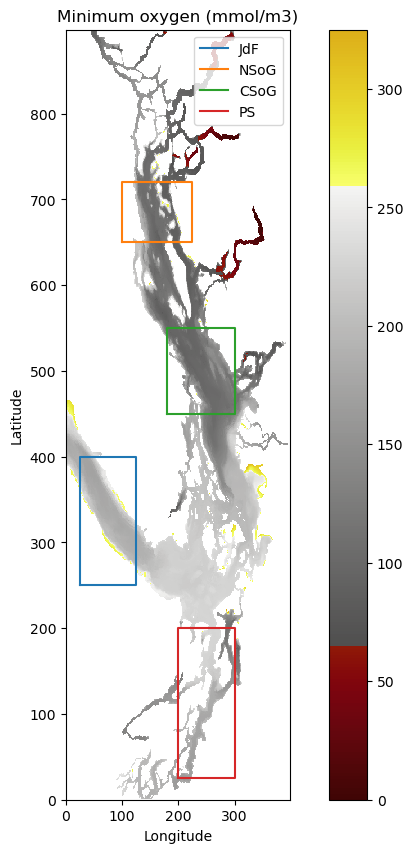

In [8]:
cmap = cmocean.cm.oxy
colors=['tab:blue','tab:orange','tab:green','tab:red']
fig, ax = plt.subplots(figsize=(10,10))
ox_0 = Ox[0,:,:,:]*mask.tmask[0,0,:,:]
oxy_min = ox_0.where(ox_0 != 0).min(skipna=True,dim='deptht')
plt.pcolormesh(oxy_min,cmap=cmap,vmax =325,vmin=0)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colors[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Minimum oxygen (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

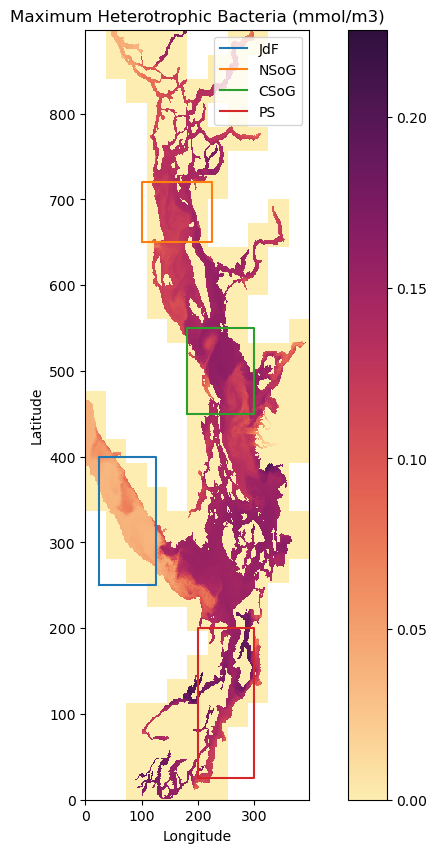

In [9]:
cmap = cmocean.cm.matter
colors=['tab:blue','tab:orange','tab:green','tab:red']
fig, ax = plt.subplots(figsize=(10,10))
hbac_t = hbac[0,:,:,:]*mask.tmask[0,0,:,:]
plt.pcolormesh(hbac_t[0,:,:],cmap=cmap)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colors[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Maximum Heterotrophic Bacteria (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [10]:
def domain_profile(
    hbac,
    mask,
    colors,
    region=None,
    regions=None,
    plot=True,
    daily_mean=False
):
    """Compute volume-weighted mean + std vertical profile optionally for a sub-region."""

    # volume mask
    volume = mask.volume
    vol = volume.where(mask.tmask == 1)

    # region slicing
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        hbac_r = hbac.isel(y=slice(y0, y1), x=slice(x0, x1))
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        hbac_r = hbac
        vol_r = vol

    # daily mean 
    if daily_mean:
        hbac_day = hbac_r.mean(dim="time_counter", skipna=True) 
    else:
        hbac_day = hbac_r
    #mean profile 
    hbac_total = (hbac_day * vol_r).sum(("z", "y", "x"))
    vol_sum = vol_r.sum(("z", "y", "x"))
    hbac_vmean = hbac_total / vol_sum

    # plot
    if plot:
        y = hbac_day.deptht.values.ravel()
        mean = hbac_vmean.values.ravel()
        plt.plot(mean, y, label=region,c=colors[region])
        plt.legend()

    return hbac_vmean

In [11]:
# path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
# day = 0
# Len = 365
# start = datetime(2024,1,1)

# mean_profiles = np.full((len(regions.keys()), Len, hbac.deptht.shape[0]),np.nan)

# for day in range(Len):
#     if day ==59:
#         print(start + timedelta(days=day))
#         continue
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         hbac = ds.heterotrophic_bacteria.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[i, day, :]  = domain_profile(hbac, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_regions_2024.npy', mean_profiles)

In [12]:
# path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
# day = 0
# Len = 365
# start = datetime(2024,1,1)

# mean_profiles = np.full((Len, hbac.deptht.shape[0]),np.nan)

# for day in range(Len):
#     if day ==59:
#         print(start + timedelta(days=day))
#         continue
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         hbac = ds.heterotrophic_bacteria.isel(time_counter=0)
#         mean_profiles[day, :]  = domain_profile(hbac, mask,colors_reg, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_full_2024.npy', mean_profiles)

Text(0.5, 1.0, 'Full Domain 2024')

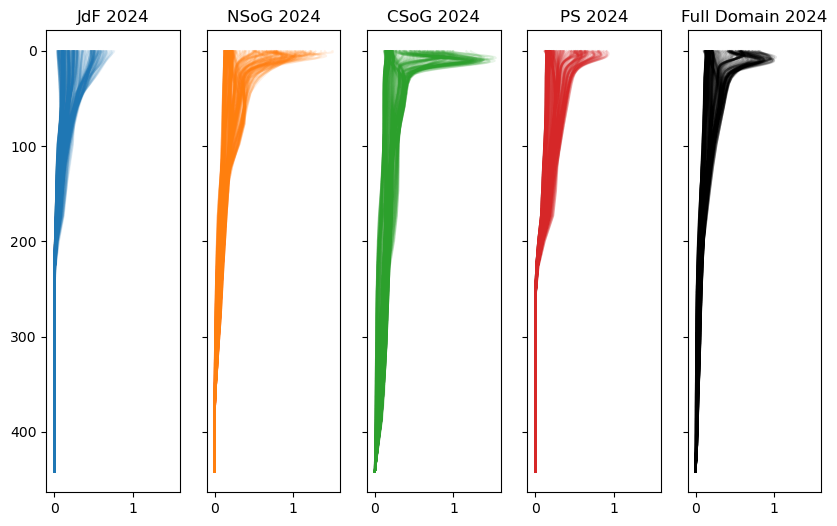

In [13]:
mean_profiles = np.load('profiles_full_2024.npy')
mean_profiles_reg = np.load('profiles_regions_2024.npy')

fig, axs = plt.subplots(1,5,figsize=(10,6),sharey=True)
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,:,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region+' 2024')
    axs[i].set_xlim(-0.1,1.6)
axs[i].invert_yaxis()

axs[4].plot(mean_profiles.T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(-0.1,1.6)
axs[4].set_title('Full Domain 2024')


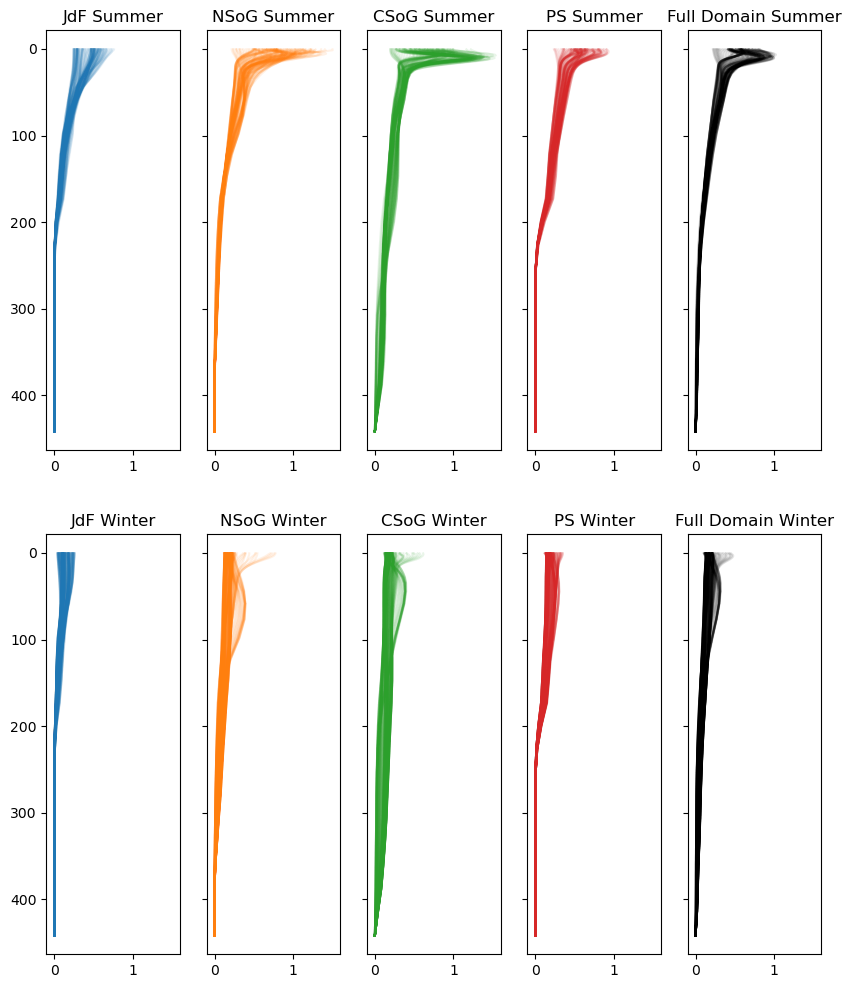

In [14]:
#From beginning of May to end of September
summer = slice(121, 274)

winter = np.ones(365, dtype=bool)
winter[summer] = False

fig, axs = plt.subplots(2,5,figsize=(10,12),sharey=True)
axs = axs.flatten()
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,summer,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region+' Summer')
    axs[i].set_xlim(-0.1,1.6)

axs[4].plot(mean_profiles[summer,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(-0.1,1.6)
axs[4].set_title('Full Domain Summer')

for i,region in enumerate(regions.keys()):
    axs[5+i].plot(mean_profiles_reg[i,winter,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[5+i].set_title(region+' Winter')
    axs[5+i].set_xlim(-0.1,1.6)

axs[9].plot(mean_profiles[winter,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[9].set_xlim(-0.1,1.6)
axs[9].set_title('Full Domain Winter')
axs[9].invert_yaxis()

In [15]:
colors_reg_winter = {'JdF':'#87CEEB','NSoG':"#F7D699",'CSoG':'#90EE90','PS':'#FFC0CB'}
colors_reg={'JdF':'#3054FC','NSoG':'#FFA500','CSoG':'#008000','PS':'#FF0000'}

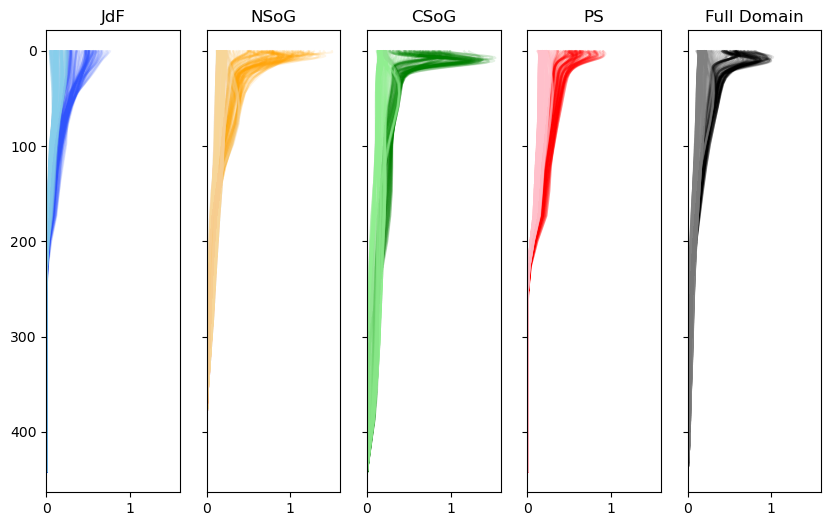

In [16]:
#From beginning of May to end of September
# mean_profiles = np.load('profiles_full_2024.npy')
# mean_profiles_reg = np.load('profiles_regions_2024.npy')

summer = slice(121, 274)

winter = np.ones(365, dtype=bool)
winter[summer] = False

xmax = 4e6/2500000

fig, axs = plt.subplots(1,5,figsize=(10,6),sharey=True)
axs = axs.flatten()
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,summer,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region)
    axs[i].set_xlim(0,xmax)

axs[4].plot(mean_profiles[summer,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(0,xmax)
axs[4].set_title('Full Domain')

for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,winter,:].T,hbac.deptht,c=colors_reg_winter[region],label=region,alpha=0.1)
    axs[i].set_title(region)
    axs[i].set_xlim(0,xmax)

axs[4].plot(mean_profiles[winter,:].T,hbac.deptht,c='grey',label='full domain',alpha=0.1)
axs[4].set_xlim(0,xmax)
axs[4].set_title('Full Domain')
axs[4].invert_yaxis()
#axs[4].set_ylim(200,-2)

In [17]:
vol = mask.volume.where(mask.tmask == 1).sel(t=0)

In [18]:
mean_profiles_2023 = np.load('profiles_full.npy')
mean_profiles_reg_2023 = np.load('profiles_regions.npy')

mean_profiles = np.append(mean_profiles_2023,mean_profiles, axis=0)
mean_profiles_reg = np.append(mean_profiles_reg_2023,mean_profiles_reg, axis=1)

Len = 730

region = 'JdF'
ii = 0
weighted_means = np.full((len(regions.keys())+1,Len), np.nan)

def weighted_mean_concentration(mean_profile,region=None,regions=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        vol_r = vol

    vol_r = vol_r.sum(axis=(1,2))
    weighted_mean = np.average(mean_profile,axis=1,weights=vol_r)
    return weighted_mean

for ii, region in enumerate(regions.keys()):
    weighted_means[ii,:] = weighted_mean_concentration(mean_profiles_reg[ii,:,:], region=region, regions=regions)


weighted_means_full = weighted_mean_concentration(mean_profiles)

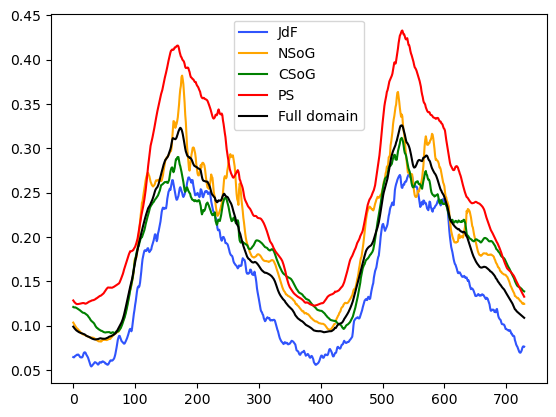

In [19]:
for ii, region in enumerate(regions.keys()):
    plt.plot(weighted_means[ii,:].T,c=colors_reg[region],label=region)
plt.plot(weighted_means_full,c='k',label='Full domain')
plt.legend()

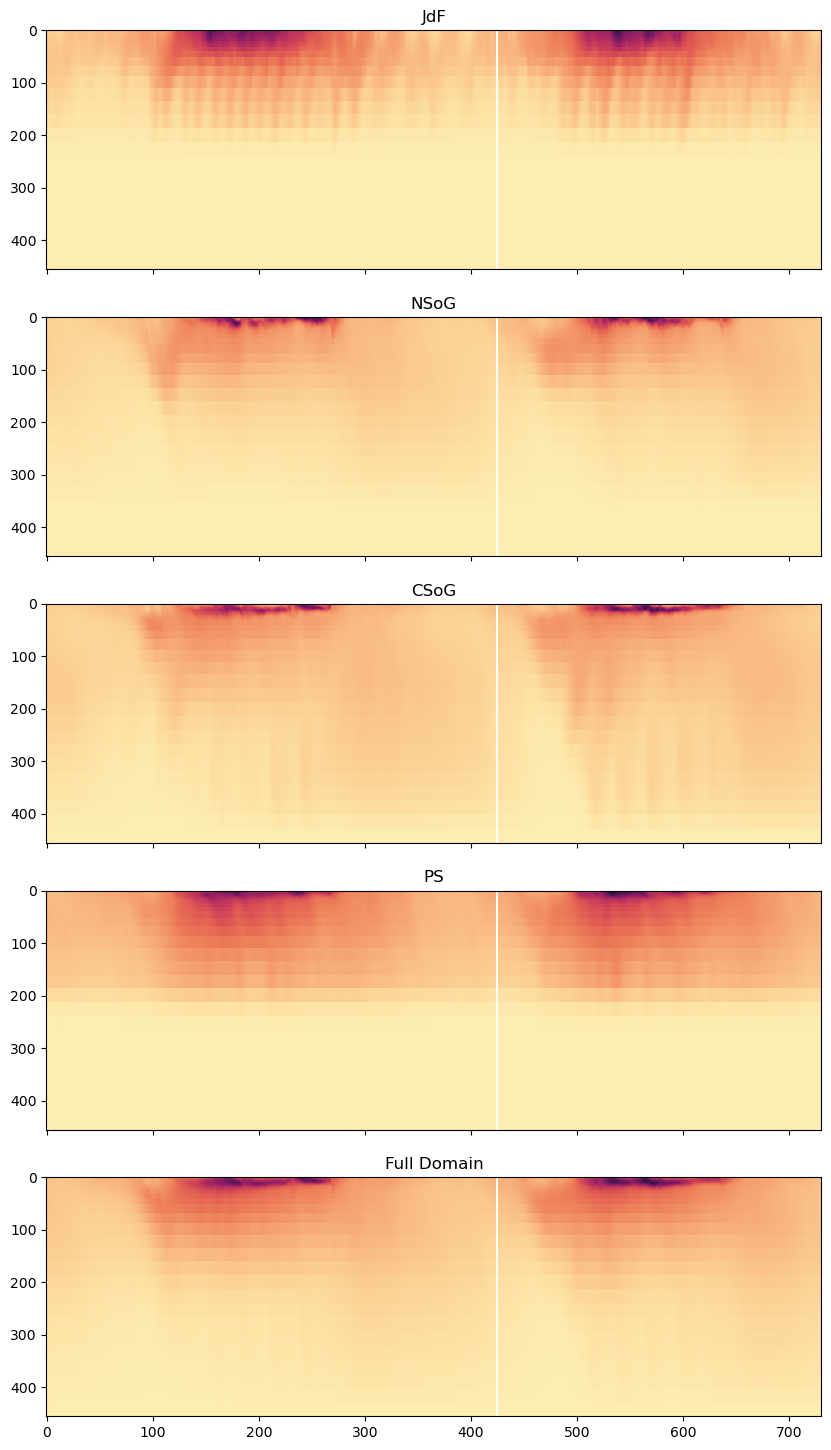

In [20]:
fig,axs = plt.subplots(5,1,figsize=(10,18),sharex=True)
time = np.linspace(0,Len,Len)
for ii, region in enumerate(regions.keys()):
    axs[ii].pcolormesh(time, mask.gdept_0[0,:,0,0],mean_profiles_reg[ii,:,:].T,cmap=cmocean.cm.matter)
    axs[ii].invert_yaxis()
    axs[ii].set_title(region)

axs[4].pcolormesh(time, mask.gdept_0[0,:,0,0], mean_profiles.T,cmap=cmocean.cm.matter)
axs[4].set_title('Full Domain')
axs[4].invert_yaxis()